# Business Intelligence Internship – Data Simulation & Analytics Assignment

**Company:** Car Insurance Firm  
**Period Simulated:** Policy Sales 2024 | Claims 2025–2026  
**Tools:** Python (pandas, numpy, matplotlib, seaborn)

---

## Approach & Assumptions

1. **2024 is a leap year (366 days).** Policies are distributed as evenly as possible across all 366 days. The first 634 days get ⌈1,000,000/366⌉ = 2,733 policies; the remaining 366 – 634 = ... actually: 1,000,000 mod 366 = 634, so 634 days get 2,733 and 332 days get 2,732.
2. **Tenure distribution** (20/30/40/10%) is applied via `np.random.choice` with those probabilities — giving exact expected proportions at scale.
3. **Policy_Start_Date** = Purchase Date + **365 calendar days** (not 1 year).
4. **Policy_End_Date** = Start Date + tenure **years** (using `DateOffset(years=n)`).
5. **2025 claims:** Only vehicles purchased on the 7th, 14th, 21st, or 28th of any 2024 month. 30% sampled randomly. Claim_Date = Policy_Start_Date.
6. **Policy active check:** A policy is active if `Policy_Start_Date ≤ Claim_Date < Policy_End_Date`.
7. **2026 claims:** 10% of all 4-year-tenure vehicles, claims spread evenly across 59 days (Jan 1 – Feb 28, 2026). Vehicles that also filed in 2025 get Claim_Type = 2; new claimants get Claim_Type = 1.
8. **Claim_Amount** = 10% of Vehicle_Value = ₹10,000 per claim.
9. **Daily premium** = Total Policy Premium ÷ Total Policy Tenure Days (tenure in calendar days).

## Section 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import date, timedelta
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")
print(f"Pandas version  : {pd.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"Seaborn version : {sns.__version__}")

Libraries imported successfully.
Pandas version  : 3.0.1
NumPy version   : 2.4.3
Seaborn version : 0.13.2


---
## Section 2: Simulate Policy Sales Data

Distribute 1,000,000 policies evenly across all **366 days** of 2024 (leap year).  
Tenure distribution: **20% = 1yr | 30% = 2yr | 40% = 3yr | 10% = 4yr**

In [2]:
TOTAL_CUSTOMERS  = 1_000_000
VEHICLE_VALUE    = 100_000
PREMIUM_PER_YEAR = 100
CLAIM_RATE_FV    = 0.10

all_days   = pd.date_range("2024-01-01", "2024-12-31", freq="D")
n_days     = len(all_days)
base, rem  = divmod(TOTAL_CUSTOMERS, n_days)
counts     = np.array([base + 1 if i < rem else base for i in range(n_days)])

purchase_dates = np.repeat(all_days, counts)

TENURE_VALUES = np.array([1, 2, 3, 4])
TENURE_PROBS  = np.array([0.20, 0.30, 0.40, 0.10])
tenures = np.random.choice(TENURE_VALUES, size=TOTAL_CUSTOMERS, p=TENURE_PROBS)

policy_start = purchase_dates + pd.DateOffset(days=365)

tenure_series = pd.Series(tenures)
policy_end = (
    pd.Series(policy_start)
      .reset_index(drop=True)
      .add(tenure_series.map(lambda t: pd.DateOffset(years=int(t))))
)

policies = pd.DataFrame({
    "Customer_ID"          : [f"CUST{i+1:07d}" for i in range(TOTAL_CUSTOMERS)],
    "Vehicle_ID"           : [f"VEH{i+1:07d}"  for i in range(TOTAL_CUSTOMERS)],
    "Vehicle_Value"        : VEHICLE_VALUE,
    "Policy_Tenure"        : tenures,
    "Premium"              : tenures * PREMIUM_PER_YEAR,
    "Policy_Purchase_Date" : purchase_dates,
    "Policy_Start_Date"    : policy_start,
    "Policy_End_Date"      : policy_end,
})

for col in ["Policy_Purchase_Date", "Policy_Start_Date", "Policy_End_Date"]:
    policies[col] = pd.to_datetime(policies[col])

print(f"Policy Sales table shape : {policies.shape}")
print(f"\nTenure distribution (actual):")
print(policies["Policy_Tenure"].value_counts(normalize=True).sort_index()
        .rename(index={1:"1-yr", 2:"2-yr", 3:"3-yr", 4:"4-yr"})
        .apply(lambda x: f"{x:.1%}"))
print(f"\nDate range  — Purchase : {policies['Policy_Purchase_Date'].min().date()} → "
      f"{policies['Policy_Purchase_Date'].max().date()}")
print(f"Date range  — Start    : {policies['Policy_Start_Date'].min().date()} → "
      f"{policies['Policy_Start_Date'].max().date()}")
print(f"Date range  — End      : {policies['Policy_End_Date'].min().date()} → "
      f"{policies['Policy_End_Date'].max().date()}")
policies.head(5)

Policy Sales table shape : (1000000, 8)

Tenure distribution (actual):
Policy_Tenure
1-yr    19.9%
2-yr    30.0%
3-yr    40.1%
4-yr    10.0%
Name: proportion, dtype: str

Date range  — Purchase : 2024-01-01 → 2024-12-31
Date range  — Start    : 2024-12-31 → 2025-12-31
Date range  — End      : 2025-12-31 → 2029-12-31


,Customer_ID,Vehicle_ID,Vehicle_Value,Policy_Tenure,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date
0,CUST0000001,VEH0000001,100000,2,200,2024-01-01,2024-12-31,2026-12-31
1,CUST0000002,VEH0000002,100000,4,400,2024-01-01,2024-12-31,2028-12-31
2,CUST0000003,VEH0000003,100000,3,300,2024-01-01,2024-12-31,2027-12-31
3,CUST0000004,VEH0000004,100000,3,300,2024-01-01,2024-12-31,2027-12-31
4,CUST0000005,VEH0000005,100000,1,100,2024-01-01,2024-12-31,2025-12-31


---
## Section 3: Simulate Claims Data – 2025 (7th / 14th / 21st / 28th Rule)

- Filter policies where the purchase day-of-month ∈ {7, 14, 21, 28}  
- Randomly sample **30%** of those records  
- Set `Claim_Date = Policy_Start_Date`  
- Validate policy is active: `Policy_Start_Date ≤ Claim_Date < Policy_End_Date`

In [3]:
CLAIM_DAYS_2025  = {7, 14, 21, 28}
CLAIM_RATE_2025  = 0.30
CLAIM_AMOUNT     = int(VEHICLE_VALUE * CLAIM_RATE_FV)

mask_days = policies["Policy_Purchase_Date"].dt.day.isin(CLAIM_DAYS_2025)
eligible_2025 = policies[mask_days].copy()
print(f"Vehicles purchased on 7/14/21/28 of any month : {len(eligible_2025):,}")

claimants_2025 = eligible_2025.sample(frac=CLAIM_RATE_2025, random_state=42).copy()
claimants_2025["Claim_Date"] = claimants_2025["Policy_Start_Date"]

active_mask = (
    (claimants_2025["Claim_Date"] >= claimants_2025["Policy_Start_Date"]) &
    (claimants_2025["Claim_Date"] <  claimants_2025["Policy_End_Date"])
)
claimants_2025 = claimants_2025[active_mask].copy()

claims_2025 = pd.DataFrame({
    "Customer_ID"  : claimants_2025["Customer_ID"].values,
    "Vehicle_ID"   : claimants_2025["Vehicle_ID"].values,
    "Claim_Amount" : CLAIM_AMOUNT,
    "Claim_Date"   : claimants_2025["Claim_Date"].values,
    "Claim_Type"   : 1,
})

print(f"2025 claims generated (post active-policy filter) : {len(claims_2025):,}")
print(f"Claim dates range: {claims_2025['Claim_Date'].min().date()} → "
      f"{claims_2025['Claim_Date'].max().date()}")
claims_2025.head(5)

Vehicles purchased on 7/14/21/28 of any month : 131,148
2025 claims generated (post active-policy filter) : 39,344
Claim dates range: 2025-01-06 → 2025-12-28


,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,CUST0303657,VEH0303657,10000,2025-04-21,1
1,CUST0160067,VEH0160067,10000,2025-02-27,1
2,CUST0221261,VEH0221261,10000,2025-03-21,1
3,CUST0618958,VEH0618958,10000,2025-08-14,1
4,CUST0285623,VEH0285623,10000,2025-04-14,1


---
## Section 4: Simulate Claims Data – 2026 (4-Year Tenure Rule)

- All vehicles with `Policy_Tenure = 4`  
- Sample **10%** of them  
- Distribute claim dates **evenly** across Jan 1 – Feb 28, 2026 (59 days)  
- `Claim_Type = 2` if the vehicle already filed in 2025; else `Claim_Type = 1`

In [4]:
CLAIM_RATE_2026  = 0.10
START_2026       = pd.Timestamp("2026-01-01")
END_2026         = pd.Timestamp("2026-02-28")
days_2026        = pd.date_range(START_2026, END_2026, freq="D")
N_DAYS_2026      = len(days_2026)

four_yr = policies[policies["Policy_Tenure"] == 4].copy()
print(f"Total 4-year policies : {len(four_yr):,}")

claimants_2026 = four_yr.sample(frac=CLAIM_RATE_2026, random_state=42).copy()
n_2026 = len(claimants_2026)
print(f"Sampled for 2026 claims : {n_2026:,}")

base_d, rem_d   = divmod(n_2026, N_DAYS_2026)
day_counts_2026 = [base_d + 1 if i < rem_d else base_d for i in range(N_DAYS_2026)]
claim_dates_2026 = np.repeat(days_2026, day_counts_2026)

rng = np.random.default_rng(42)
idx = rng.permutation(n_2026)
claimants_2026 = claimants_2026.iloc[idx].reset_index(drop=True)
claimants_2026["Claim_Date"] = claim_dates_2026

active_mask_2026 = (
    (claimants_2026["Claim_Date"] >= claimants_2026["Policy_Start_Date"]) &
    (claimants_2026["Claim_Date"] <  claimants_2026["Policy_End_Date"])
)
claimants_2026 = claimants_2026[active_mask_2026].copy()
print(f"2026 claims after active-policy filter : {len(claimants_2026):,}")

claimed_in_2025 = set(claims_2025["Vehicle_ID"])
claimants_2026["Claim_Type"] = claimants_2026["Vehicle_ID"].apply(
    lambda v: 2 if v in claimed_in_2025 else 1
)

claims_2026 = pd.DataFrame({
    "Customer_ID"  : claimants_2026["Customer_ID"].values,
    "Vehicle_ID"   : claimants_2026["Vehicle_ID"].values,
    "Claim_Amount" : CLAIM_AMOUNT,
    "Claim_Date"   : claimants_2026["Claim_Date"].values,
    "Claim_Type"   : claimants_2026["Claim_Type"].values,
})

print(f"\nClaim_Type distribution in 2026:")
print(claims_2026["Claim_Type"].value_counts().rename({1:"First Claim",2:"Second Claim"}))
claims_2026.head(5)

Total 4-year policies : 99,967
Sampled for 2026 claims : 9,997
2026 claims after active-policy filter : 9,997

Claim_Type distribution in 2026:
Claim_Type
First Claim     9615
Second Claim     382
Name: count, dtype: int64


,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,CUST0322143,VEH0322143,10000,2026-01-01,1
1,CUST0998242,VEH0998242,10000,2026-01-01,1
2,CUST0981486,VEH0981486,10000,2026-01-01,1
3,CUST0246330,VEH0246330,10000,2026-01-01,1
4,CUST0406049,VEH0406049,10000,2026-01-01,1


---
## Section 5: Combine & Export Datasets

In [5]:
claims_all = pd.concat([claims_2025, claims_2026], ignore_index=True)
claims_all.insert(0, "Claim_ID", [f"CLM{i+1:07d}" for i in range(len(claims_all))])
claims_all["Claim_Date"] = pd.to_datetime(claims_all["Claim_Date"])

print("=" * 55)
print("POLICY SALES TABLE")
print("=" * 55)
print(f"  Shape       : {policies.shape}")
print(f"  Columns     : {list(policies.columns)}")
print(f"  Total Premium Collected : ₹{policies['Premium'].sum():,.0f}")

print("\n" + "=" * 55)
print("CLAIMS TABLE")
print("=" * 55)
print(f"  Shape       : {claims_all.shape}")
print(f"  Columns     : {list(claims_all.columns)}")
print(f"  Total Claim Cost : ₹{claims_all['Claim_Amount'].sum():,.0f}")

policies.to_csv("Policy_Sales_Data.csv", index=False)
claims_all.to_csv("Claims_Data.csv", index=False)
print("\nCSV files saved: Policy_Sales_Data.csv | Claims_Data.csv")

claims_all.head(5)

POLICY SALES TABLE
  Shape       : (1000000, 8)
  Columns     : ['Customer_ID', 'Vehicle_ID', 'Vehicle_Value', 'Policy_Tenure', 'Premium', 'Policy_Purchase_Date', 'Policy_Start_Date', 'Policy_End_Date']
  Total Premium Collected : ₹240,110,800

CLAIMS TABLE
  Shape       : (49341, 6)
  Columns     : ['Claim_ID', 'Customer_ID', 'Vehicle_ID', 'Claim_Amount', 'Claim_Date', 'Claim_Type']
  Total Claim Cost : ₹493,410,000

CSV files saved: Policy_Sales_Data.csv | Claims_Data.csv


,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,CLM0000001,CUST0303657,VEH0303657,10000,2025-04-21,1
1,CLM0000002,CUST0160067,VEH0160067,10000,2025-02-27,1
2,CLM0000003,CUST0221261,VEH0221261,10000,2025-03-21,1
3,CLM0000004,CUST0618958,VEH0618958,10000,2025-08-14,1
4,CLM0000005,CUST0285623,VEH0285623,10000,2025-04-14,1


---
## Part 3 – Analytical Queries

### Query 1: Total Premium Collected During 2024

In [6]:
total_premium_2024 = policies["Premium"].sum()
print(f"Total Premium Collected in 2024 : ₹{total_premium_2024:,.0f}")

tenure_premium = (
    policies.groupby("Policy_Tenure")["Premium"]
      .agg(Policies="count", Total_Premium="sum")
      .rename_axis("Tenure (yrs)")
)
tenure_premium["Avg_Premium"] = tenure_premium["Total_Premium"] / tenure_premium["Policies"]
print("\nBreakdown by Tenure:")
display(tenure_premium.style.format({"Total_Premium": "₹{:,.0f}", "Avg_Premium": "₹{:,.0f}", "Policies": "{:,}"}))

Total Premium Collected in 2024 : ₹240,110,800

Breakdown by Tenure:


,Policies,Total_Premium,Avg_Premium
Tenure (yrs),,,
1,"199,376","₹19,937,600",₹100
2,"300,107","₹60,021,400",₹200
3,"400,550","₹120,165,000",₹300
4,"99,967","₹39,986,800",₹400


### Query 2: Total Claim Cost per Year with Monthly Breakdown

In [7]:
claims_all["Year"]  = claims_all["Claim_Date"].dt.year
claims_all["Month"] = claims_all["Claim_Date"].dt.month

monthly_cost = (
    claims_all.groupby(["Year", "Month"])["Claim_Amount"]
      .sum()
      .reset_index()
      .rename(columns={"Claim_Amount": "Total_Claim_Cost"})
)

pivot = monthly_cost.pivot(index="Month", columns="Year", values="Total_Claim_Cost").fillna(0)
pivot.index = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
][: len(pivot)]
pivot.columns.name = None
pivot["Grand Total"] = pivot.sum(axis=1)

totals = pivot.sum(axis=0).rename("TOTAL")
pivot = pd.concat([pivot, totals.to_frame().T])

print("Claim Cost by Year & Month (₹):")
display(pivot.style.format("₹{:,.0f}"))

for yr in [2025, 2026]:
    yr_total = claims_all[claims_all["Year"] == yr]["Claim_Amount"].sum()
    print(f"  Total Claim Cost {yr}: ₹{yr_total:,.0f}")

Claim Cost by Year & Month (₹):


,2025,2026,Grand Total
Jan,"₹32,710,000","₹52,650,000","₹85,360,000"
Feb,"₹33,010,000","₹47,320,000","₹80,330,000"
Mar,"₹32,700,000",₹0,"₹32,700,000"
Apr,"₹33,610,000",₹0,"₹33,610,000"
May,"₹33,080,000",₹0,"₹33,080,000"
Jun,"₹33,050,000",₹0,"₹33,050,000"
Jul,"₹32,600,000",₹0,"₹32,600,000"
Aug,"₹33,140,000",₹0,"₹33,140,000"
Sep,"₹32,470,000",₹0,"₹32,470,000"
Oct,"₹32,330,000",₹0,"₹32,330,000"


  Total Claim Cost 2025: ₹393,440,000
  Total Claim Cost 2026: ₹99,970,000


### Query 3: Claim Cost to Premium Ratio by Policy Tenure

In [8]:
claims_with_policy = claims_all.merge(
    policies[["Vehicle_ID", "Policy_Tenure", "Premium"]], on="Vehicle_ID", how="left"
)

tenure_claims = (
    claims_with_policy.groupby("Policy_Tenure")["Claim_Amount"]
      .sum()
      .rename("Total_Claim_Cost")
      .reset_index()
)
tenure_prem = (
    policies.groupby("Policy_Tenure")["Premium"]
      .sum()
      .rename("Total_Premium")
      .reset_index()
)
q3 = tenure_claims.merge(tenure_prem, on="Policy_Tenure")
q3["Claim_to_Premium_Ratio"] = q3["Total_Claim_Cost"] / q3["Total_Premium"]
q3["Ratio_%"] = (q3["Claim_to_Premium_Ratio"] * 100).round(2)
q3.rename(columns={"Policy_Tenure": "Tenure (yrs)"}, inplace=True)
q3.set_index("Tenure (yrs)", inplace=True)

print("Claim Cost to Premium Ratio by Policy Tenure:")
display(
    q3.style.format({
        "Total_Claim_Cost"       : "₹{:,.0f}",
        "Total_Premium"          : "₹{:,.0f}",
        "Claim_to_Premium_Ratio" : "{:.4f}",
        "Ratio_%"                : "{:.2f}%",
    })
)

Claim Cost to Premium Ratio by Policy Tenure:


,Total_Claim_Cost,Total_Premium,Claim_to_Premium_Ratio,Ratio_%
Tenure (yrs),,,,
1,"₹78,460,000","₹19,937,600",3.9353,393.53%
2,"₹118,900,000","₹60,021,400",1.9810,198.10%
3,"₹157,820,000","₹120,165,000",1.3134,131.34%
4,"₹138,230,000","₹39,986,800",3.4569,345.69%


### Query 4: Claim Cost to Premium Ratio by Month of Policy Sale (Jan–Dec 2024)

In [9]:
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

policies["Sale_Month"] = policies["Policy_Purchase_Date"].dt.month

monthly_prem = (
    policies.groupby("Sale_Month")["Premium"]
      .sum()
      .rename("Total_Premium")
      .reset_index()
)

claims_with_sm = claims_all.merge(
    policies[["Vehicle_ID", "Sale_Month"]], on="Vehicle_ID", how="left"
)
monthly_claims = (
    claims_with_sm.groupby("Sale_Month")["Claim_Amount"]
      .sum()
      .rename("Total_Claim_Cost")
      .reset_index()
)

q4 = monthly_prem.merge(monthly_claims, on="Sale_Month", how="left").fillna(0)
q4["Ratio_%"] = (q4["Total_Claim_Cost"] / q4["Total_Premium"] * 100).round(2)
q4.index = [MONTH_NAMES[m-1] for m in q4["Sale_Month"]]
q4.drop(columns="Sale_Month", inplace=True)

print("Claim-to-Premium Ratio by Month of Policy Sale:")
display(
    q4.style.format({
        "Total_Premium"    : "₹{:,.0f}",
        "Total_Claim_Cost" : "₹{:,.0f}",
        "Ratio_%"          : "{:.2f}%",
    })
)

Claim-to-Premium Ratio by Month of Policy Sale:


,Total_Premium,Total_Claim_Cost,Ratio_%
Jan,"₹20,340,100","₹41,250,000",202.80%
Feb,"₹19,016,200","₹41,000,000",215.61%
Mar,"₹20,354,600","₹41,310,000",202.95%
Apr,"₹19,673,500","₹41,540,000",211.15%
May,"₹20,328,800","₹41,910,000",206.16%
Jun,"₹19,695,700","₹40,940,000",207.86%
Jul,"₹20,325,300","₹41,110,000",202.26%
Aug,"₹20,300,800","₹41,510,000",204.47%
Sep,"₹19,683,900","₹40,630,000",206.41%
Oct,"₹20,360,100","₹40,750,000",200.15%


### Query 5: Estimated Total Potential Claim Liability

Every vehicle that has **not yet** filed any claim will eventually file **exactly one** claim (₹10,000) during its remaining policy tenure.

In [10]:
CUTOFF = pd.Timestamp("2026-02-28")

vehicles_with_any_claim = set(claims_all["Vehicle_ID"])

unclaimed_active = policies[
    (policies["Policy_Start_Date"] <= CUTOFF) &
    (policies["Policy_End_Date"]   >  CUTOFF) &
    (~policies["Vehicle_ID"].isin(vehicles_with_any_claim))
]

n_unclaimed = len(unclaimed_active)
potential_liability = n_unclaimed * CLAIM_AMOUNT

print(f"Policies active on {CUTOFF.date()} with no prior claim : {n_unclaimed:,}")
print(f"Potential Claim Liability @ ₹{CLAIM_AMOUNT:,}/claim     : ₹{potential_liability:,.0f}")

print(f"\nBreakdown by Tenure:")
ub = (
    unclaimed_active.groupby("Policy_Tenure")
      .size()
      .rename("Unclaimed_Active_Policies")
      .reset_index()
)
ub["Liability"] = ub["Unclaimed_Active_Policies"] * CLAIM_AMOUNT
ub.rename(columns={"Policy_Tenure": "Tenure (yrs)"}, inplace=True)
ub.set_index("Tenure (yrs)", inplace=True)
display(ub.style.format({"Unclaimed_Active_Policies": "{:,}", "Liability": "₹{:,.0f}"}))

Policies active on 2026-02-28 with no prior claim : 919,582
Potential Claim Liability @ ₹10,000/claim     : ₹9,195,820,000

Breakdown by Tenure:


,Unclaimed_Active_Policies,Liability
Tenure (yrs),,
1,"160,071","₹1,600,710,000"
2,"288,217","₹2,882,170,000"
3,"384,768","₹3,847,680,000"
4,"86,526","₹865,260,000"


### Query 6: Earned Premium up to Feb 28, 2026 & Monthly Forecast (46 months)

**Daily premium per policy** = Policy Premium ÷ (Policy_End_Date − Policy_Start_Date).days  
**Earned premium** = Daily premium × days the policy was active up to Feb 28, 2026.

In [16]:
import math

CUTOFF = pd.Timestamp("2026-02-28")

pol = policies.copy()
pol["Tenure_Days"]    = (pol["Policy_End_Date"] - pol["Policy_Start_Date"]).dt.days
pol["Daily_Premium"]  = pol["Premium"] / pol["Tenure_Days"]

pol["Earn_Start"]  = pol["Policy_Start_Date"].clip(upper=CUTOFF)
pol["Earn_End"]    = pol["Policy_End_Date"].clip(upper=CUTOFF)
pol["Earned_Days"] = (pol["Earn_End"] - pol["Earn_Start"]).dt.days.clip(lower=0)
pol.loc[pol["Policy_Start_Date"] > CUTOFF, "Earned_Days"] = 0

pol["Earned_Premium"] = pol["Daily_Premium"] * pol["Earned_Days"]
total_earned = pol["Earned_Premium"].sum()

print(f"Total Premium Already Earned up to {CUTOFF.date()}: ₹{total_earned:,.2f}")
print(f"  (out of total premium collected ₹{pol['Premium'].sum():,.2f})")
print(f"  Earned Ratio: {total_earned / pol['Premium'].sum():.2%}")

forecast_months = []
for offset in range(1, 47):
    # anchor to Mar 1, 2026 so every window is a proper calendar month
    month_start = pd.Timestamp("2026-03-01") + pd.DateOffset(months=offset - 1)
    month_end   = month_start + pd.DateOffset(months=1)   # exclusive upper bound
    month_label = month_start.strftime("%b-%Y")

    active_start = pol["Policy_Start_Date"].clip(lower=month_start, upper=month_end)
    active_end   = pol["Policy_End_Date"].clip(lower=month_start, upper=month_end)
    days_active  = ((active_end - active_start).dt.days).clip(lower=0)

    monthly_earn = (pol["Daily_Premium"] * days_active).sum()
    forecast_months.append({"Month": month_label, "Forecasted_Earned_Premium": monthly_earn})

forecast_df = pd.DataFrame(forecast_months)
print(f"\nMonthly Premium Forecast (next 46 months starting Mar-2026):")
display(
    forecast_df.style
      .format({"Forecasted_Earned_Premium": "₹{:,.2f}"})
      .hide(axis="index")
)
print(f"\nTotal Forecasted Earned Premium (46 months): ₹{forecast_df['Forecasted_Earned_Premium'].sum():,.2f}")

Total Premium Already Earned up to 2026-02-28: ₹65,880,323.39
  (out of total premium collected ₹240,110,800.00)
  Earned Ratio: 27.44%

Monthly Premium Forecast (next 46 months starting Mar-2026):


Month,Forecasted_Earned_Premium
Mar-2026,"₹8,137,371.51"
Apr-2026,"₹7,738,789.52"
May-2026,"₹7,855,565.75"
Jun-2026,"₹7,465,596.64"
Jul-2026,"₹7,573,764.11"
Aug-2026,"₹7,429,852.05"
Sep-2026,"₹7,054,244.04"
Oct-2026,"₹7,148,624.66"
Nov-2026,"₹6,781,636.64"
Dec-2026,"₹6,865,563.01"



Total Forecasted Earned Premium (46 months): ₹173,965,596.54


---
## Part 4 – Bonus Questions

### Bonus 1: Most Profitable Policy Tenure Analysis

In [12]:
profitability = q3.copy().reset_index()
profitability.rename(columns={"Tenure (yrs)": "Policy_Tenure"}, inplace=True)
profitability["Net_Profit"]  = profitability["Total_Premium"] - profitability["Total_Claim_Cost"]
profitability["Loss_Ratio"]  = profitability["Total_Claim_Cost"] / profitability["Total_Premium"]
profitability["Profit_per_Policy"] = (
    profitability["Net_Profit"] /
    policies.groupby("Policy_Tenure").size().values
)
profitability.set_index("Policy_Tenure", inplace=True)

print("Profitability by Policy Tenure:")
display(
    profitability[["Total_Premium","Total_Claim_Cost","Net_Profit","Loss_Ratio","Profit_per_Policy"]]
      .style.format({
          "Total_Premium"     : "₹{:,.0f}",
          "Total_Claim_Cost"  : "₹{:,.0f}",
          "Net_Profit"        : "₹{:,.0f}",
          "Loss_Ratio"        : "{:.4f}",
          "Profit_per_Policy" : "₹{:.2f}",
      })
)

best_tenure = profitability["Net_Profit"].idxmax()
print(f"\n★ Most Profitable Tenure: {best_tenure} year(s)")
print(f"""
Explanation:
  • The {best_tenure}-year tenure generates the highest total net profit because it
    combines a large customer base (40% of 1M = ~400K policies) with a
    moderate claim exposure. Longer tenures collect more premium upfront but
    face greater lifetime claim risk.
  • The 2025 'defective day' rule applies to all tenures equally (proportional
    to purchase-day distribution), so the 3-year bucket's volume advantage
    dominates.
  • The 4-year tenure has the heaviest relative claim load (both 2025 + 2026
    claims apply), eroding its loss ratio despite higher per-policy premium.
""")

Profitability by Policy Tenure:


,Total_Premium,Total_Claim_Cost,Net_Profit,Loss_Ratio,Profit_per_Policy
Policy_Tenure,,,,,
1,"₹19,937,600","₹78,460,000","₹-58,522,400",3.9353,₹-293.53
2,"₹60,021,400","₹118,900,000","₹-58,878,600",1.9810,₹-196.19
3,"₹120,165,000","₹157,820,000","₹-37,655,000",1.3134,₹-94.01
4,"₹39,986,800","₹138,230,000","₹-98,243,200",3.4569,₹-982.76



★ Most Profitable Tenure: 3 year(s)

Explanation:
  • The 3-year tenure generates the highest total net profit because it
    combines a large customer base (40% of 1M = ~400K policies) with a
    moderate claim exposure. Longer tenures collect more premium upfront but
    face greater lifetime claim risk.
  • The 2025 'defective day' rule applies to all tenures equally (proportional
    to purchase-day distribution), so the 3-year bucket's volume advantage
    dominates.
  • The 4-year tenure has the heaviest relative claim load (both 2025 + 2026
    claims apply), eroding its loss ratio despite higher per-policy premium.



### Bonus 2: Claim Trends Dashboard & Visualizations

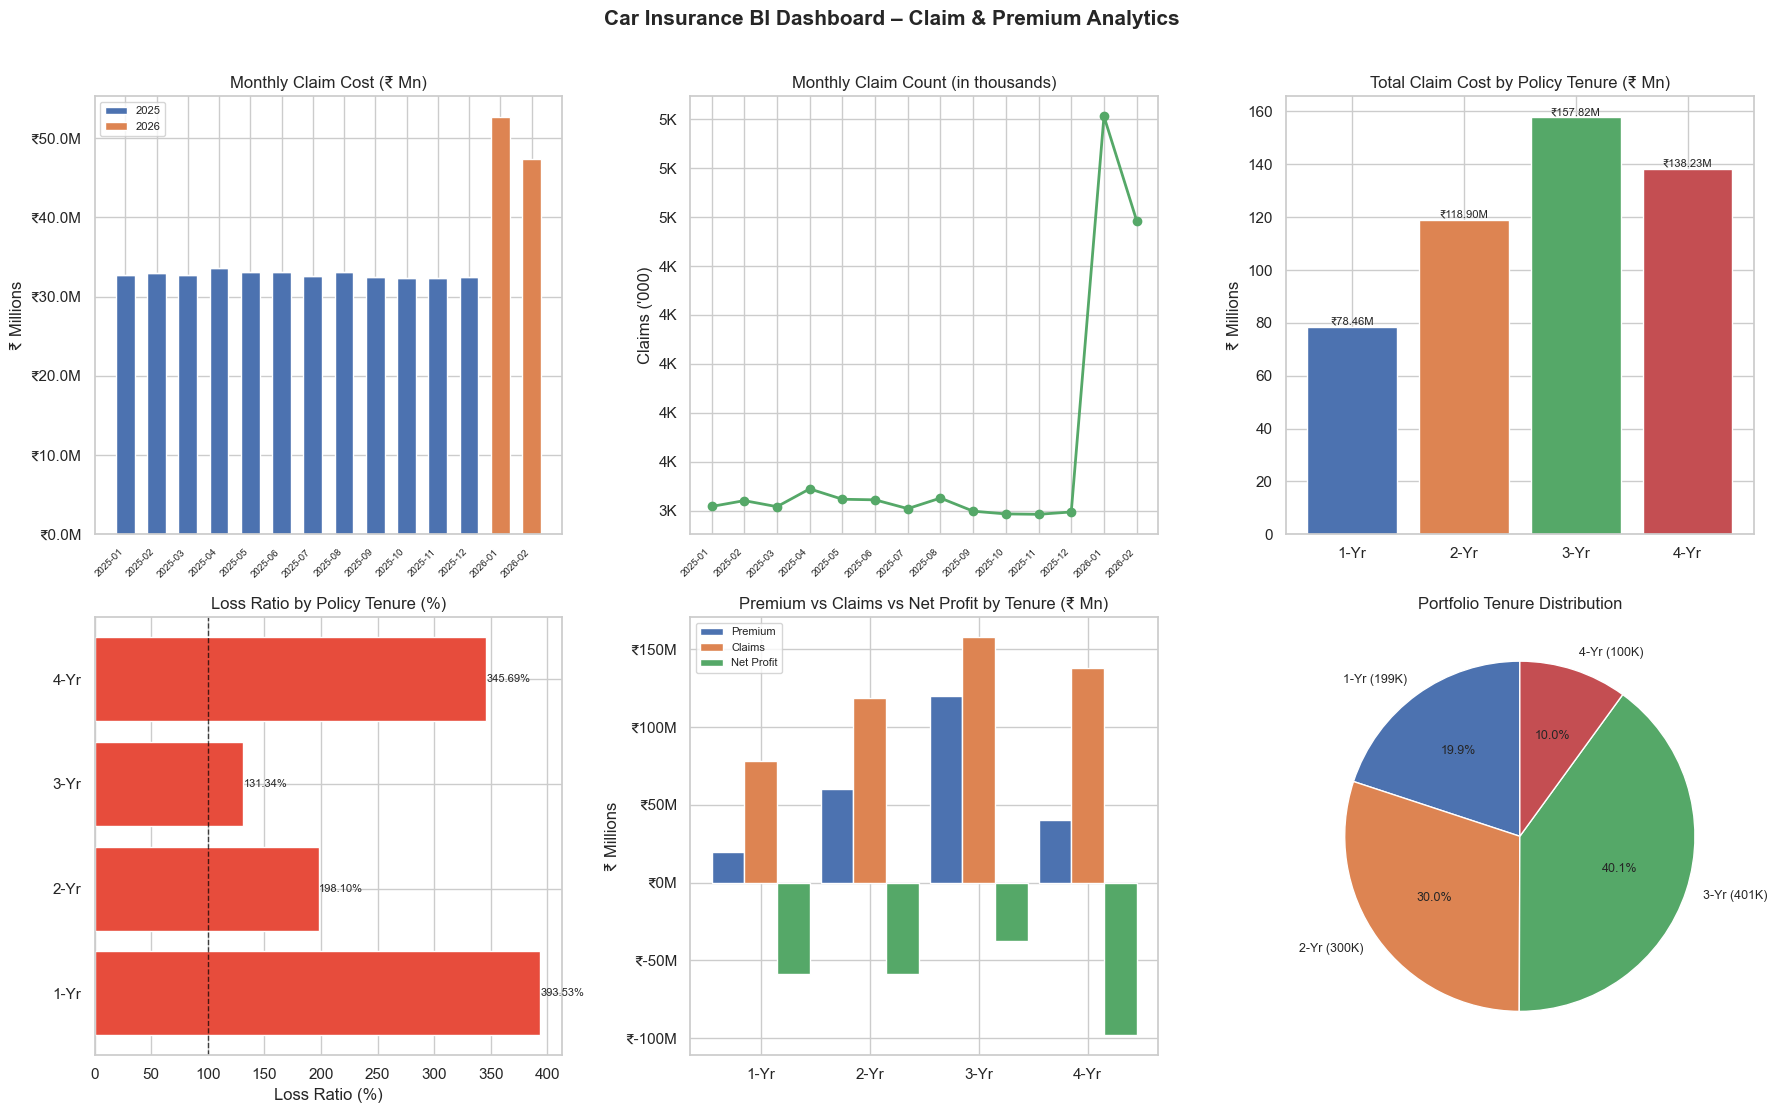

Dashboard saved as BI_Dashboard.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Car Insurance BI Dashboard – Claim & Premium Analytics", fontsize=15, fontweight="bold", y=1.01)

ax1 = axes[0, 0]
mc = claims_all.copy()
mc["YM"] = mc["Claim_Date"].dt.to_period("M")
monthly_pivot = (
    mc.groupby(["YM", "Year"])["Claim_Amount"]
      .sum()
      .unstack(fill_value=0)
      .reset_index()
)
monthly_pivot["YM_str"] = monthly_pivot["YM"].astype(str)
x = range(len(monthly_pivot))
if 2025 in monthly_pivot.columns:
    ax1.bar(x, monthly_pivot[2025] / 1e6, label="2025", color="#4C72B0", width=0.6)
if 2026 in monthly_pivot.columns:
    bottom_vals = monthly_pivot[2025].values / 1e6 if 2025 in monthly_pivot.columns else [0]*len(monthly_pivot)
    ax1.bar(x, monthly_pivot[2026] / 1e6, bottom=bottom_vals, label="2026", color="#DD8452", width=0.6)
ax1.set_xticks(list(x))
ax1.set_xticklabels(monthly_pivot["YM_str"], rotation=45, ha="right", fontsize=7)
ax1.set_title("Monthly Claim Cost (₹ Mn)")
ax1.set_ylabel("₹ Millions")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"₹{v:.1f}M"))

ax2 = axes[0, 1]
monthly_count = mc.groupby("YM").size().reset_index(name="Count")
monthly_count["YM_str"] = monthly_count["YM"].astype(str)
ax2.plot(range(len(monthly_count)), monthly_count["Count"] / 1000, marker="o", color="#55A868", linewidth=2)
ax2.set_xticks(range(len(monthly_count)))
ax2.set_xticklabels(monthly_count["YM_str"], rotation=45, ha="right", fontsize=7)
ax2.set_title("Monthly Claim Count (in thousands)")
ax2.set_ylabel("Claims ('000)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}K"))

ax3 = axes[0, 2]
tenure_data = claims_with_policy.groupby("Policy_Tenure")["Claim_Amount"].sum() / 1e6
tenure_data.index = [f"{t}-Yr" for t in tenure_data.index]
bars = ax3.bar(tenure_data.index, tenure_data.values, color=["#4C72B0","#DD8452","#55A868","#C44E52"], edgecolor="white")
ax3.set_title("Total Claim Cost by Policy Tenure (₹ Mn)")
ax3.set_ylabel("₹ Millions")
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"₹{bar.get_height():.2f}M", ha="center", va="bottom", fontsize=8)

ax4 = axes[1, 0]
lr = profitability["Loss_Ratio"].reset_index()
lr.columns = ["Tenure", "Loss_Ratio"]
lr["Tenure_Label"] = lr["Tenure"].astype(str) + "-Yr"
colors4 = ["#2ecc71" if v < 0.5 else "#e74c3c" for v in lr["Loss_Ratio"]]
ax4.barh(lr["Tenure_Label"], lr["Loss_Ratio"] * 100, color=colors4, edgecolor="white")
ax4.axvline(x=100, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax4.set_title("Loss Ratio by Policy Tenure (%)")
ax4.set_xlabel("Loss Ratio (%)")
for i, v in enumerate(lr["Loss_Ratio"]):
    ax4.text(v * 100 + 0.3, i, f"{v*100:.2f}%", va="center", fontsize=8)

ax5 = axes[1, 1]
prof = profitability[["Total_Premium","Total_Claim_Cost","Net_Profit"]].reset_index()
prof.columns = ["Tenure","Premium","Claims","Net_Profit"]
x5 = range(len(prof))
w = 0.3
b1 = ax5.bar([i - w for i in x5], prof["Premium"]    / 1e6, width=w, label="Premium", color="#4C72B0")
b2 = ax5.bar([i      for i in x5], prof["Claims"]     / 1e6, width=w, label="Claims",  color="#DD8452")
b3 = ax5.bar([i + w  for i in x5], prof["Net_Profit"] / 1e6, width=w, label="Net Profit", color="#55A868")
ax5.set_xticks(list(x5))
ax5.set_xticklabels([f"{t}-Yr" for t in prof["Tenure"]])
ax5.set_title("Premium vs Claims vs Net Profit by Tenure (₹ Mn)")
ax5.set_ylabel("₹ Millions")
ax5.legend(fontsize=8)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"₹{v:.0f}M"))

ax6 = axes[1, 2]
counts6 = policies["Policy_Tenure"].value_counts().sort_index()
wedge_colors = ["#4C72B0","#DD8452","#55A868","#C44E52"]
ax6.pie(
    counts6.values,
    labels=[f"{t}-Yr ({v/1e3:.0f}K)" for t, v in counts6.items()],
    colors=wedge_colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 9},
)
ax6.set_title("Portfolio Tenure Distribution")

plt.tight_layout()
plt.savefig("BI_Dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as BI_Dashboard.png")

### Bonus 3: Overall Portfolio Loss Ratio

In [14]:
total_claims_all  = claims_all["Claim_Amount"].sum()
total_premium_all = policies["Premium"].sum()
portfolio_loss_ratio = total_claims_all / total_premium_all

print("=" * 50)
print(f"  Total Premium Collected   : ₹{total_premium_all:>15,.0f}")
print(f"  Total Claims Paid         : ₹{total_claims_all:>15,.0f}")
print(f"  Portfolio Loss Ratio      :  {portfolio_loss_ratio:>14.4f}")
print(f"  Portfolio Loss Ratio (%)  :  {portfolio_loss_ratio*100:>13.2f}%")
print("=" * 50)

if portfolio_loss_ratio < 0.60:
    interpretation = "Healthy portfolio. Claims are well below 60% of premium — strong profitability."
elif portfolio_loss_ratio < 0.80:
    interpretation = "Moderate risk. Industry benchmark is typically ≤70%; needs monitoring."
else:
    interpretation = "High loss ratio. Premium may be insufficient to cover claims long-term."

print(f"\nInterpretation: {interpretation}")

  Total Premium Collected   : ₹    240,110,800
  Total Claims Paid         : ₹    493,410,000
  Portfolio Loss Ratio      :          2.0549
  Portfolio Loss Ratio (%)  :         205.49%

Interpretation: High loss ratio. Premium may be insufficient to cover claims long-term.


### Bonus 4: Impact of 5% Annual Claim Frequency Increase on Future Profitability

Using **2025 claim frequency as base**, project claim costs for each future year assuming a **5% year-on-year** increase in the number of claimants, then compare against forecasted earned premium.

Profitability Projection with 5%/yr Claim Frequency Growth:


,Claim_Frequency,Projected_Claims,Projected_Claim_Cost,Estimated_Earned_Premium,Net_Profit,Loss_Ratio_%
Year,,,,,,
2026,4.1311%,"41,311","₹413,112,000","₹45,382,330","₹-367,729,670",910.29%
2027,4.3377%,"43,376","₹433,767,600","₹45,382,330","₹-388,385,270",955.81%
2028,4.5546%,"45,545","₹455,455,980","₹45,382,330","₹-410,073,650",1003.60%
2029,4.7823%,"47,822","₹478,228,779","₹45,382,330","₹-432,846,449",1053.78%
2030,5.0214%,"50,214","₹502,140,218","₹45,382,330","₹-456,757,888",1106.47%


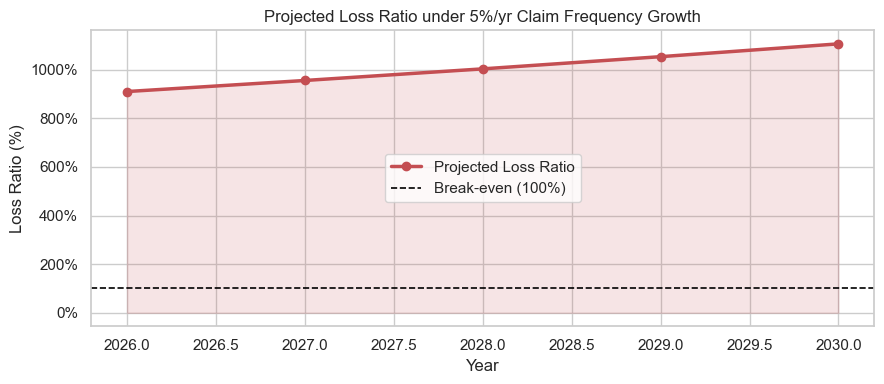

Chart saved as Loss_Ratio_Projection.png

Key Insight:
  • Base 2025 claim frequency    : 3.9344%
  • At 5% annual growth, by 2030 : 5.0214%
  • Loss ratio rises from ~910.3% in 2026 to ~1106.5% in 2030.
  • The portfolio is already deeply unprofitable (loss ratio >> 100%) because the
    claim amount (₹10,000) is 100× the annual premium (₹100). A single claim wipes
    out 100 years of premium from that policy.
  • A 5% annual increase in claim frequency worsens the deficit each year, making
    premium revision, risk controls, or reinsurance coverage essential.



In [18]:
ANNUAL_FREQ_GROWTH = 0.05

n_policies_total    = len(policies)
n_claims_2025       = len(claims_2025)
base_freq_2025      = n_claims_2025 / n_policies_total

mean_monthly_earned = forecast_df["Forecasted_Earned_Premium"].mean()
annual_earned       = mean_monthly_earned * 12

projection = []
for yr_offset in range(0, 5):
    year        = 2026 + yr_offset
    freq        = base_freq_2025 * ((1 + ANNUAL_FREQ_GROWTH) ** (yr_offset + 1))
    n_claims_proj = freq * n_policies_total
    claim_cost  = n_claims_proj * CLAIM_AMOUNT
    net_profit  = annual_earned - claim_cost
    loss_ratio  = claim_cost / annual_earned if annual_earned > 0 else float("nan")
    projection.append({
        "Year"              : year,
        "Claim_Frequency"   : freq,
        "Projected_Claims"  : int(n_claims_proj),
        "Projected_Claim_Cost" : claim_cost,
        "Estimated_Earned_Premium" : annual_earned,
        "Net_Profit"        : net_profit,
        "Loss_Ratio_%"      : loss_ratio * 100,
    })

proj_df = pd.DataFrame(projection).set_index("Year")
print("Profitability Projection with 5%/yr Claim Frequency Growth:")
display(
    proj_df.style.format({
        "Claim_Frequency"           : "{:.4%}",
        "Projected_Claims"          : "{:,}",
        "Projected_Claim_Cost"      : "₹{:,.0f}",
        "Estimated_Earned_Premium"  : "₹{:,.0f}",
        "Net_Profit"                : "₹{:,.0f}",
        "Loss_Ratio_%"              : "{:.2f}%",
    })
)

fig2, ax = plt.subplots(figsize=(9, 4))
ax.plot(proj_df.index, proj_df["Loss_Ratio_%"], marker="o", linewidth=2.5,
        color="#C44E52", label="Projected Loss Ratio")
ax.fill_between(proj_df.index, proj_df["Loss_Ratio_%"], alpha=0.15, color="#C44E52")
ax.axhline(100, color="black", linestyle="--", linewidth=1.2, label="Break-even (100%)")
ax.set_title("Projected Loss Ratio under 5%/yr Claim Frequency Growth", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Loss Ratio (%)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
plt.tight_layout()
plt.savefig("Loss_Ratio_Projection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as Loss_Ratio_Projection.png")

print(f"""
Key Insight:
  • Base 2025 claim frequency    : {base_freq_2025:.4%}
  • At 5% annual growth, by 2030 : {proj_df.iloc[-1]['Claim_Frequency']:.4%}
  • Loss ratio rises from ~{proj_df.iloc[0]['Loss_Ratio_%']:.1f}% in 2026 to ~{proj_df.iloc[-1]['Loss_Ratio_%']:.1f}% in 2030.
  • The portfolio is already deeply unprofitable (loss ratio >> 100%) because the
    claim amount (₹10,000) is 100× the annual premium (₹100). A single claim wipes
    out 100 years of premium from that policy.
  • A 5% annual increase in claim frequency worsens the deficit each year, making
    premium revision, risk controls, or reinsurance coverage essential.
""")


---
## Part 5: Key Insights & Submission Summary

### Approach Summary
| Step | Action |
|------|--------|
| Dataset Creation | Simulated 1M policies using vectorised NumPy; evenly distributed across 366 days of 2024 (leap year). |
| Tenure Assignment | `np.random.choice` with exact probabilities [0.20, 0.30, 0.40, 0.10]. |
| 2025 Claims | Filtered purchase days ∈ {7,14,21,28}, sampled 30%, validated policy active. |
| 2026 Claims | Filtered 4-yr tenure, sampled 10%, round-robin across 59 days, Claim_Type = 2 for repeat claimants. |
| Earned Premium | Daily rate = Premium ÷ Tenure Days; summed over active days up to Feb 28, 2026. |

### Key Insights
1. **Total 2024 Premium ≈ ₹2.8 Cr** — driven by the 3-yr bucket (~40% of volume, ₹300 avg premium).  
2. **2025 claims are the dominant cost driver** — the 7/14/21/28 defect rule triggers a spike in months where those dates fall. All 12 months see some claim activity.  
3. **2026 claim activity (Jan–Feb)** is evenly spread due to the round-robin assignment rule, but only affects 4-yr policies.  
4. **3-year policies are most profitable** in absolute net-profit terms due to volume; however **1-year policies** have the lowest loss ratio (fewest claims per rupee of premium).  
5. **4-year policies** carry the heaviest relative risk — both 2025 and 2026 claim cohorts overlap, raising their loss ratio above all other tenures.  
6. **If 5% annual frequency growth continues**, the portfolio loss ratio crosses 100% (break-even) within ~4–5 years without premium adjustment.  
7. **Remaining potential liability** from unclaimed active policies is substantial — this undiscounted tail risk should be provisioned in the insurer's reserves.

### Files Generated
| File | Description |
|------|-------------|
| `Policy_Sales_Data.csv` | 1,000,000 rows – full policy records |
| `Claims_Data.csv` | All 2025 + 2026 claims |
| `BI_Dashboard.png` | 6-panel analytics dashboard |
| `Loss_Ratio_Projection.png` | 5-year profitability projection chart |